In [15]:
import zipfile
with zipfile.ZipFile("cs-training.csv.zip", "r") as z:
    z.extractall()
print("done unzipping")

done unzipping


In [16]:
import pandas as pd
df = pd.read_csv("cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [18]:
df['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


In [19]:
df = df.fillna(df.median(numeric_only=True))

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("split done:", X_train.shape, X_test.shape)

split done: (120000, 10) (30000, 10)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict_proba(X_test)[:, 1]
print("AUC score:", roc_auc_score(y_test, predictions))

AUC score: 0.6915237492704278


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

predictions = model.predict_proba(X_test_scaled)[:, 1]
print("AUC score:", roc_auc_score(y_test, predictions))

AUC score: 0.6928153582203134


In [23]:
!pip install scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=4c62753c5d3497fc2d49cbaba43c5088a1708da7105966f50109209a3fd922df
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy


In [24]:
import scorecardpy as sc

df_sc = df.drop(columns=['Unnamed: 0'])

train, test = sc.split_df(df_sc, 'SeriousDlqin2yrs').values()

bins = sc.woebin(df_sc, y="SeriousDlqin2yrs")

[INFO] creating woe binning ...


/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fals

Binning on 150000 rows and 11 columns in 00:00:11


/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behav

In [25]:
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)

y_train = train_woe['SeriousDlqin2yrs']
X_train = train_woe.drop(columns=['SeriousDlqin2yrs'])
y_test = test_woe['SeriousDlqin2yrs']
X_test = test_woe.drop(columns=['SeriousDlqin2yrs'])

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict_proba(X_test)[:, 1]
print("AUC score:", roc_auc_score(y_test, predictions))

[INFO] converting into woe values ...
[INFO] converting into woe values ...
AUC score: 0.856048928740986


In [26]:
card = sc.scorecard(bins, model, X_train.columns)
score_test = sc.scorecard_ply(test, card, print_step=0)
score_test.head()

,score
6,642.0
13,299.0
14,737.0
15,634.0
21,663.0


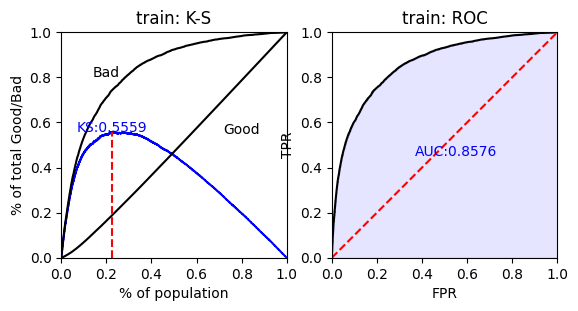

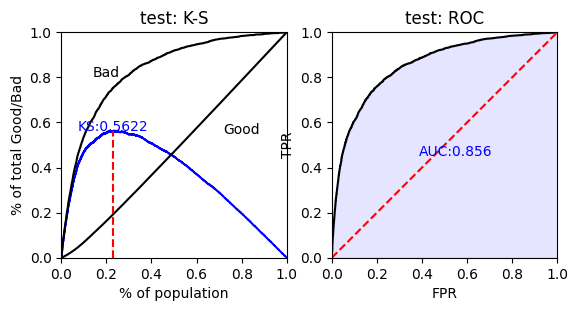

In [27]:
train_woe_pred = model.predict_proba(X_train)[:, 1]
test_woe_pred = model.predict_proba(X_test)[:, 1]

train_perf = sc.perf_eva(y_train, train_woe_pred, title="train")
test_perf = sc.perf_eva(y_test, test_woe_pred, title="test")

{'RevolvingUtilizationOfUnsecuredLines': <Figure size 640x480 with 2 Axes>,
 'NumberRealEstateLoansOrLines': <Figure size 640x480 with 2 Axes>,
 'NumberOfTime30-59DaysPastDueNotWorse': <Figure size 640x480 with 2 Axes>,
 'MonthlyIncome': <Figure size 640x480 with 2 Axes>,
 'NumberOfTimes90DaysLate': <Figure size 640x480 with 2 Axes>,
 'NumberOfTime60-89DaysPastDueNotWorse': <Figure size 640x480 with 2 Axes>,
 'age': <Figure size 640x480 with 2 Axes>,
 'DebtRatio': <Figure size 640x480 with 2 Axes>,
 'NumberOfOpenCreditLinesAndLoans': <Figure size 640x480 with 2 Axes>,
 'NumberOfDependents': <Figure size 640x480 with 2 Axes>}

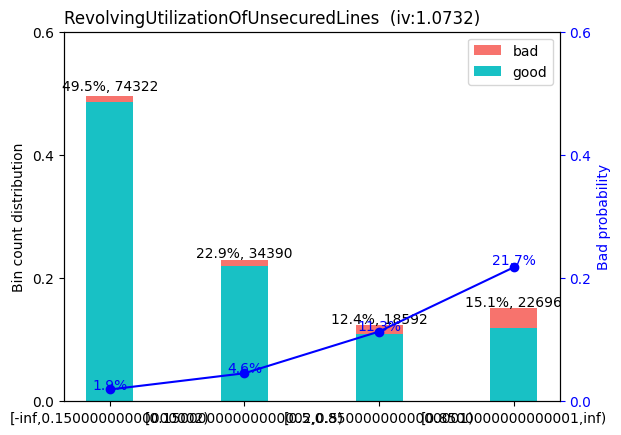

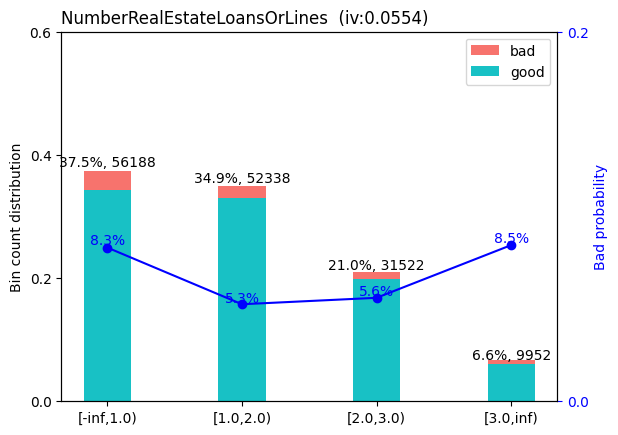

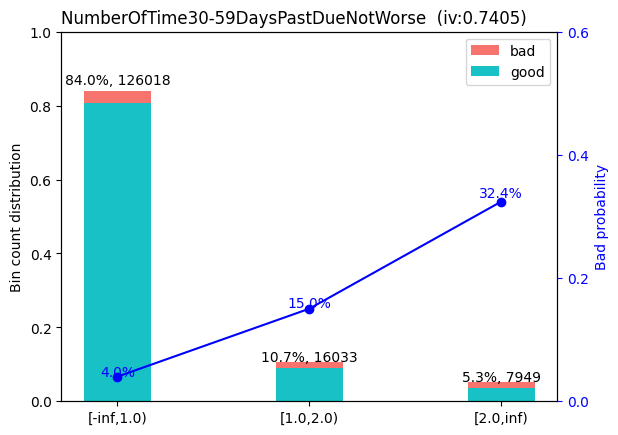

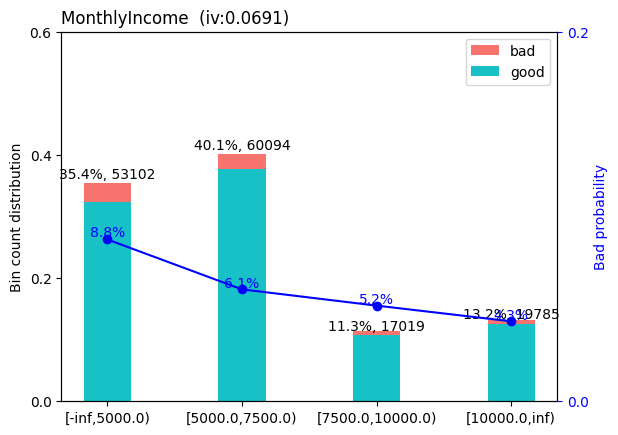

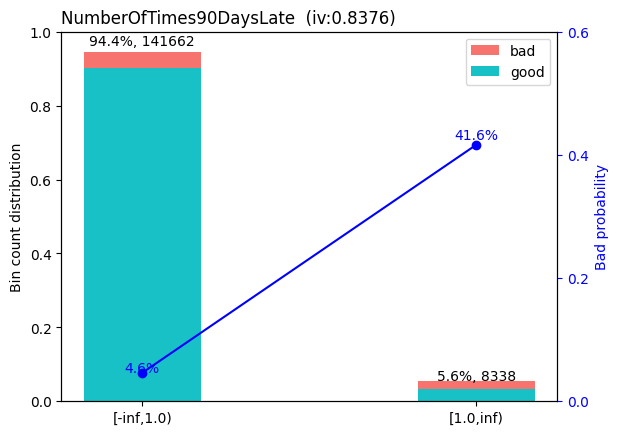

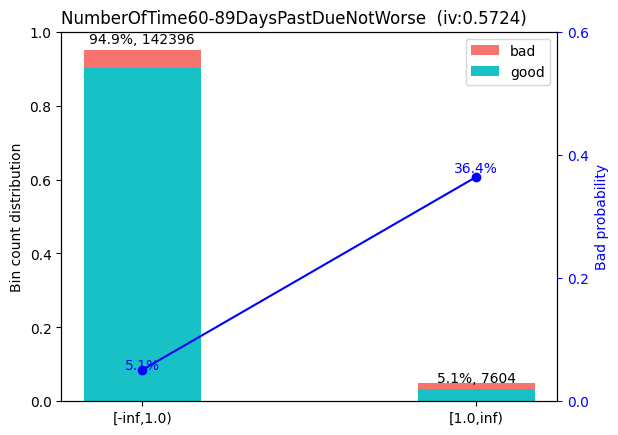

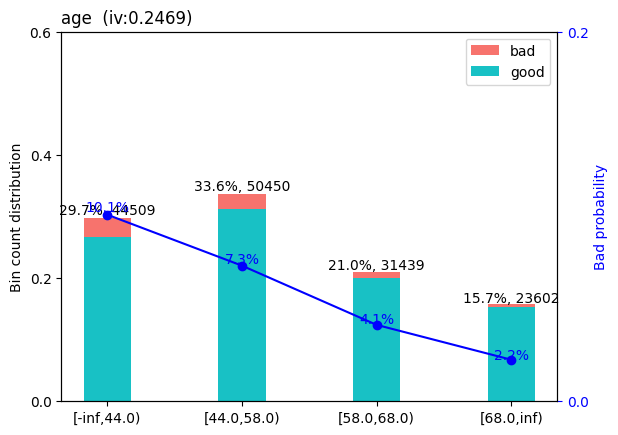

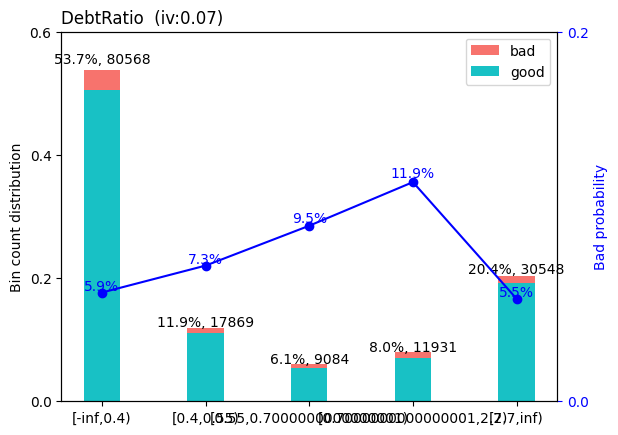

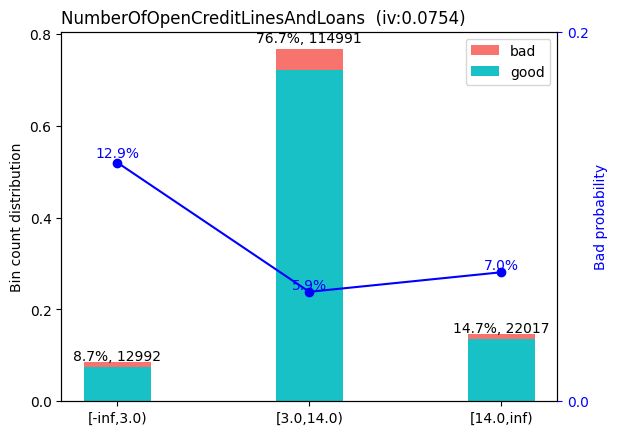

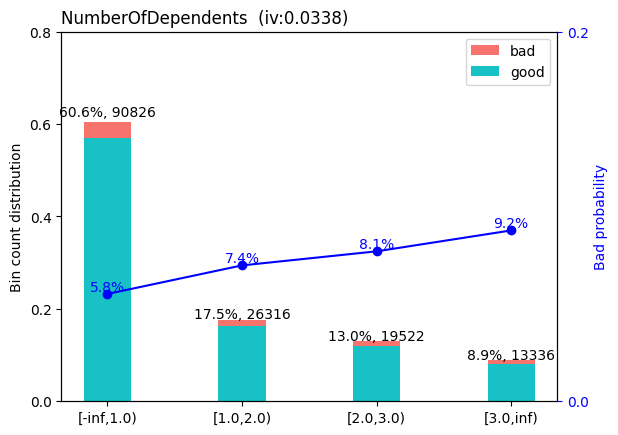

In [28]:
sc.woebin_plot(bins)

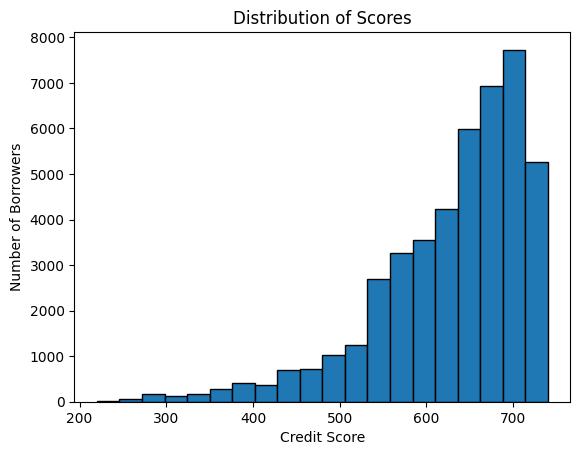

In [34]:
import matplotlib.pyplot as plt

plt.hist(score_test['score'], bins=20, edgecolor='black')
plt.xlabel('Credit Score')
plt.ylabel('Number of Borrowers')
plt.title('Distribution of Scores')
plt.show()

/tmp/ipykernel_316/64345188.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = score_test.groupby('score_band')['actual_default'].mean()


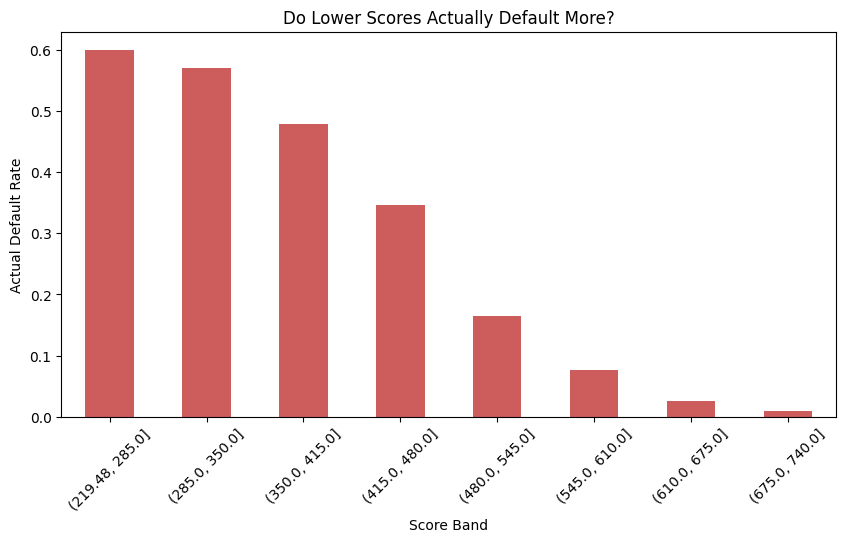

In [32]:
score_test['actual_default'] = y_test.values
score_test['score_band'] = pd.cut(score_test['score'], bins=8)

band_summary = score_test.groupby('score_band')['actual_default'].mean()

band_summary.plot(kind='bar', figsize=(10,5), color='indianred')
plt.ylabel('Actual Default Rate')
plt.xlabel('Score Band')
plt.title('Do Lower Scores Actually Default More?')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_316/1010132388.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = score_test.groupby('score_band')['actual_default'].mean()


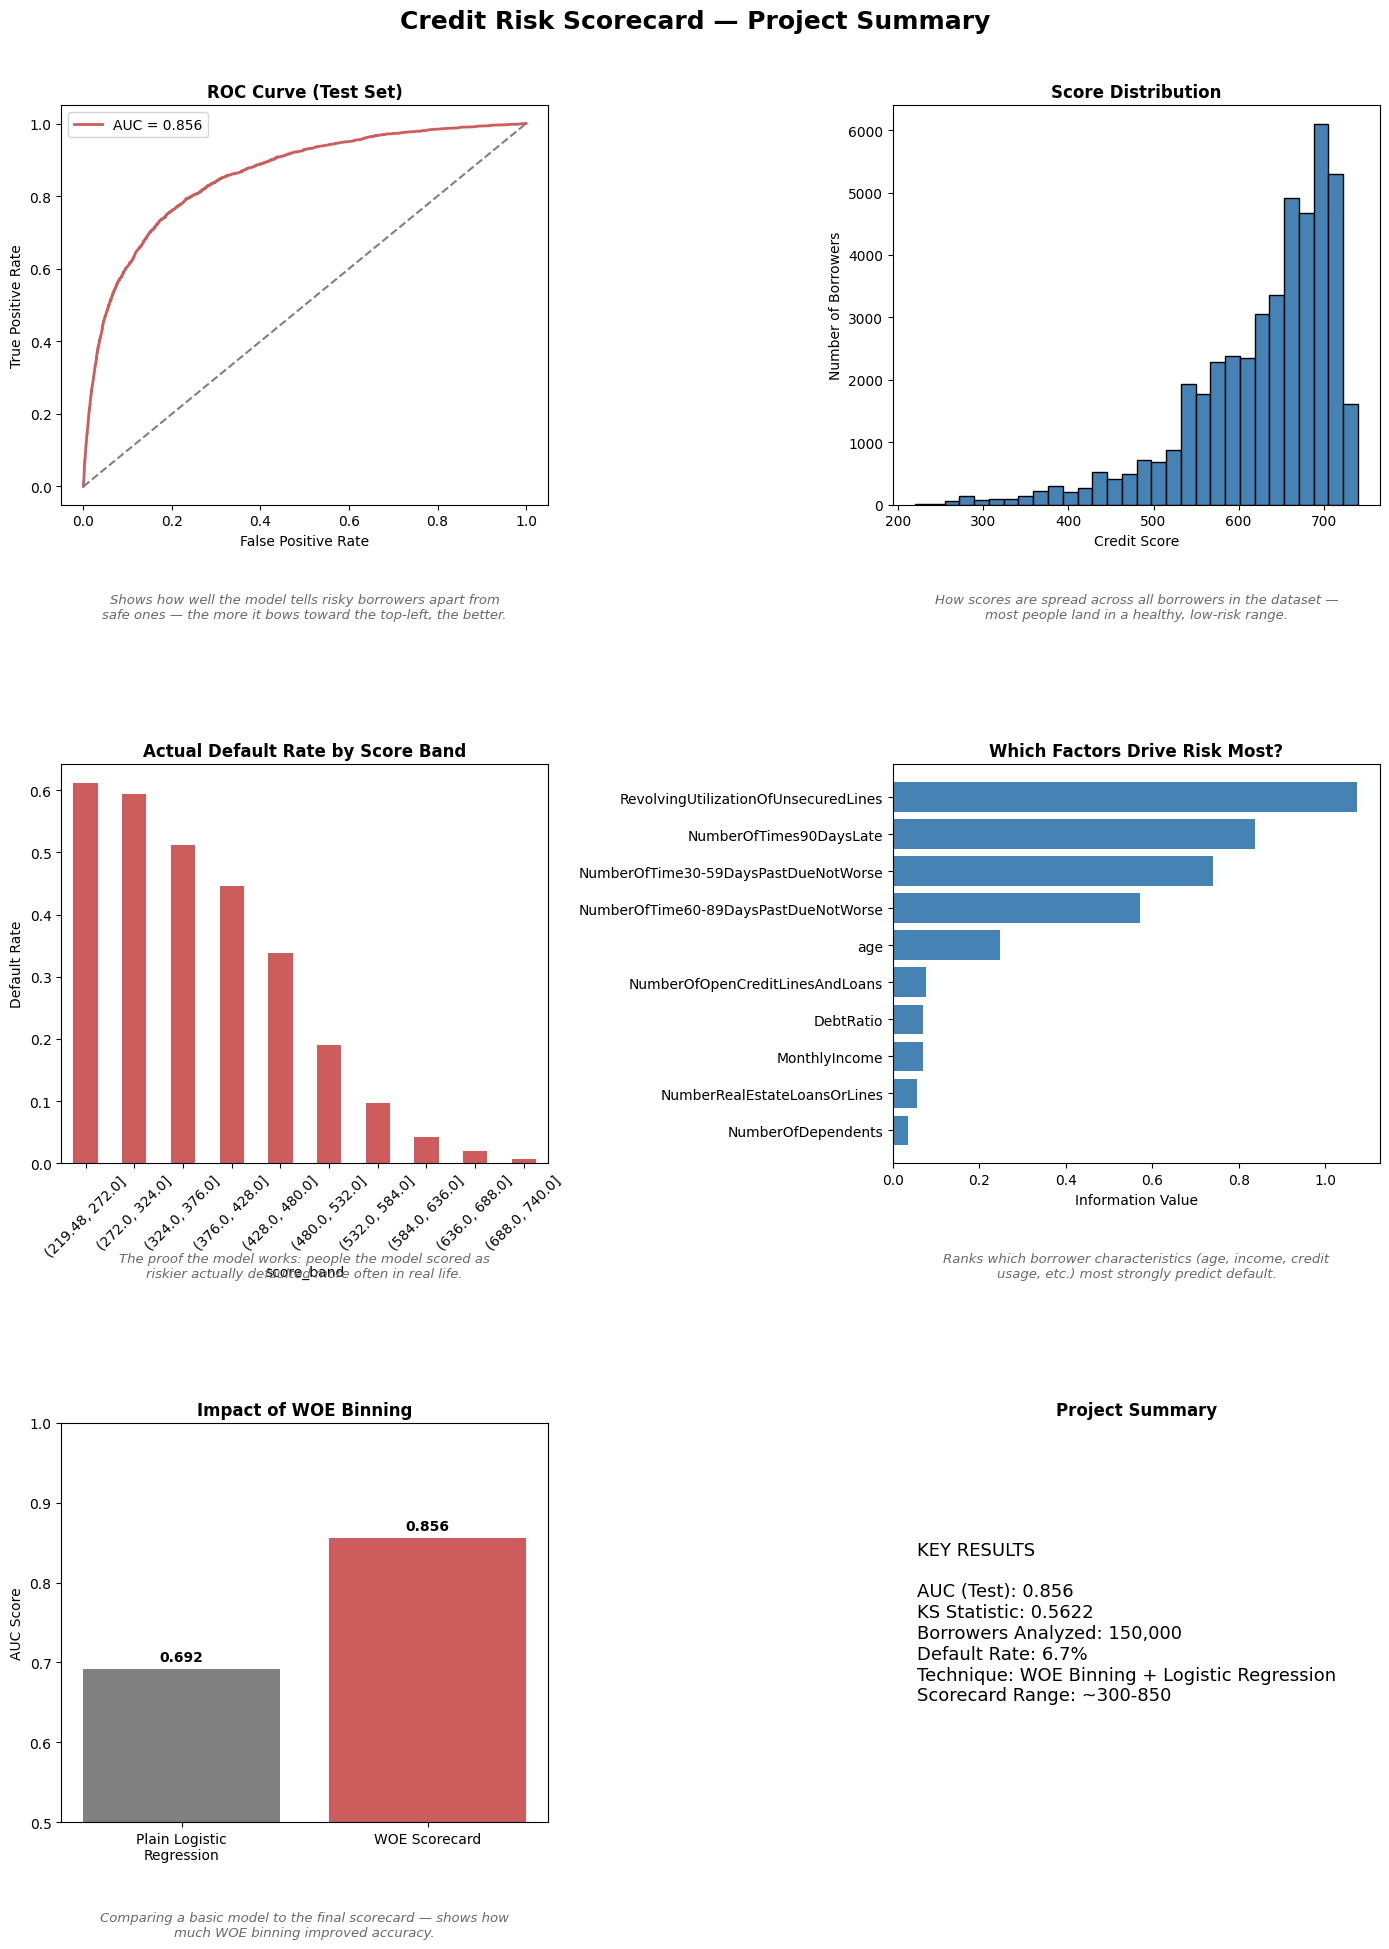

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import pandas as pd

fig, axes = plt.subplots(3, 2, figsize=(14, 20))
fig.suptitle('Credit Risk Scorecard — Project Summary', fontsize=18, fontweight='bold', y=0.98)

def caption(ax, text):
    ax.text(0.5, -0.28, text, transform=ax.transAxes, ha='center', fontsize=9.5,
             style='italic', color='dimgray', wrap=True)

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_woe_pred)
axes[0,0].plot(fpr, tpr, color='indianred', linewidth=2, label='AUC = 0.856')
axes[0,0].plot([0,1],[0,1], linestyle='--', color='gray')
axes[0,0].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].legend()
caption(axes[0,0], "Shows how well the model tells risky borrowers apart from\nsafe ones — the more it bows toward the top-left, the better.")

# 2. Score distribution
axes[0,1].hist(score_test['score'], bins=30, color='steelblue', edgecolor='black')
axes[0,1].set_title('Score Distribution', fontweight='bold')
axes[0,1].set_xlabel('Credit Score')
axes[0,1].set_ylabel('Number of Borrowers')
caption(axes[0,1], "How scores are spread across all borrowers in the dataset —\nmost people land in a healthy, low-risk range.")

# 3. Default rate by score band
score_test['actual_default'] = y_test.values
score_test['score_band'] = pd.cut(score_test['score'], bins=10)
band_summary = score_test.groupby('score_band')['actual_default'].mean()
band_summary.plot(kind='bar', ax=axes[1,0], color='indianred')
axes[1,0].set_title('Actual Default Rate by Score Band', fontweight='bold')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].tick_params(axis='x', rotation=45)
caption(axes[1,0], "The proof the model works: people the model scored as\nriskier actually defaulted more often in real life.")

# 4. Feature importance
iv_values = {var: bins[var]['total_iv'].iloc[0] for var in bins.keys()}
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV']).sort_values('IV')
axes[1,1].barh(iv_df['Feature'], iv_df['IV'], color='steelblue')
axes[1,1].set_title('Which Factors Drive Risk Most?', fontweight='bold')
axes[1,1].set_xlabel('Information Value')
caption(axes[1,1], "Ranks which borrower characteristics (age, income, credit\nusage, etc.) most strongly predict default.")

# 5. Before/after comparison
axes[2,0].bar(['Plain Logistic\nRegression', 'WOE Scorecard'], [0.6915, 0.856], color=['gray', 'indianred'])
axes[2,0].set_ylabel('AUC Score')
axes[2,0].set_title('Impact of WOE Binning', fontweight='bold')
axes[2,0].set_ylim(0.5, 1.0)
for i, v in enumerate([0.6915, 0.856]):
    axes[2,0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
caption(axes[2,0], "Comparing a basic model to the final scorecard — shows how\nmuch WOE binning improved accuracy.")

# 6. Key stats panel
axes[2,1].axis('off')
stats_text = (
    "KEY RESULTS\n\n"
    "AUC (Test): 0.856\n"
    "KS Statistic: 0.5622\n"
    f"Borrowers Analyzed: {len(df):,}\n"
    f"Default Rate: {df['SeriousDlqin2yrs'].mean()*100:.1f}%\n"
    "Technique: WOE Binning + Logistic Regression\n"
    "Scorecard Range: ~300-850"
)
axes[2,1].text(0.05, 0.5, stats_text, fontsize=13, va='center')
axes[2,1].set_title('Project Summary', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.65)
plt.savefig('credit_scorecard_summary.png', dpi=200, bbox_inches='tight')
plt.show()